# Fitting single flow curve

This notebook contains examples focusing on the analysis and visualization of a flow curve. A flow curve is the measurement of the viscosity as a function of shear rate. In a measurement a constant shear rate is imposed on a fluid sample and the required shear stress is measured. 

Since for Non newtonian fluids the viscosity is a function of the shear rate, the flow curve measurement is a way to characterize such functional dependence. 

Rheological models can be used to fit the flow curve and extract parameters that in some case directly relates to fundamental material properties.

In this notebook we provide some example of analysis of flow curves using powerful python libraries that we simply integrate to make flow curves analysis simple, easy to share and reproduce.

We provide a sequence of examples structured as "recipes" each with a specific scope, plotting data, fitting data, evaluating confidence intervals...

In [1]:
import rheofit
import pybroom as pb
import matplotlib.pyplot as plt
import pandas as pd

## Getting Example flow curve data

To make demonstration simple we stored an example flow curve in the rheodata module. 

the cp2pc_pg dataset is a rheological dataset of a carbopol 2% in propylene glycol, measured on a stress-controlled rheometer with a cone-plate geometry.

In [2]:
from rheofit.rheodata import HA1pc_water
#High molecular weight hyaluronic acid in water, 1% w/w
HA1pc_water

Experiment(...)

## Plotting flow curve data
To plot the data we use matplolib. We define a simple function that plot the data, set x and y scale to log and the label for x and y. The function return a matplolib figure object that can be stored in a variable.

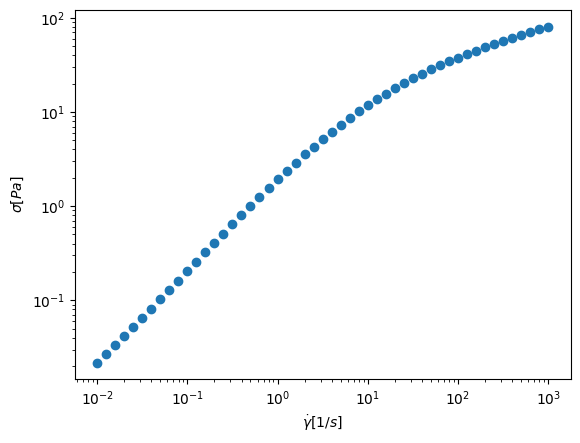

In [3]:
data=HA1pc_water.get_dataframes_by_step('processed')[1][2]
def plot_data(data):
    plt.plot(data['Shear rate / 1/s'],data['Stress / Pa'],'o')
    plt.yscale('log')
    plt.xscale('log')
    plt.ylabel(r'$\sigma [Pa]$');
    plt.xlabel(r'$\dot\gamma [1/s]$');
    
    return plt.gcf()

fig1=plot_data(data);

## Fitting flow curve data to a rheological model
This is the most important functionality mostly provided by the [LMFIT](https://lmfit.github.io/lmfit-py/) library. The rheofit module just provide the rheology model definition and documentation. 

For example a popular model for yield stress fluids is the Hershel Bulckley model is a lmfit.Model object

In [4]:
model=rheofit.models.carreau_model
model

Model(carreau, prefix='carreau_')

To fit the data we use the fit method of the model object passing the **stress**, the **shear rate** and the weights

# Parameter initialization

In [28]:
# Parameter initialization is important for the convergence of the fit. Here we use the following strategy:

# check the default parameters
params=model.make_params()
params

name,value,initial value,min,max,vary
carreau_eta_0,1.00000000,None,0.00000000,inf,True
carreau_gammadot_crit,1.00000000,None,0.00000000,inf,True
carreau_n,0.50000000,None,0.00000000,1.00000000,True
carreau_eta_inf,1.0000e-03,None,0.00000000,inf,True


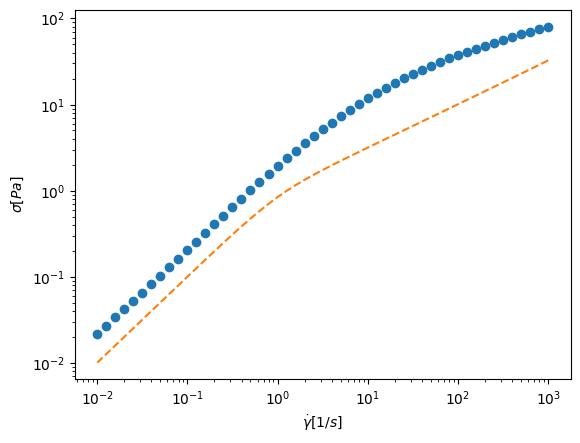

In [29]:
plot_data(data)
plt.plot(data['Shear rate / 1/s'],model.eval(x=data['Shear rate / 1/s'], params=params),'--')

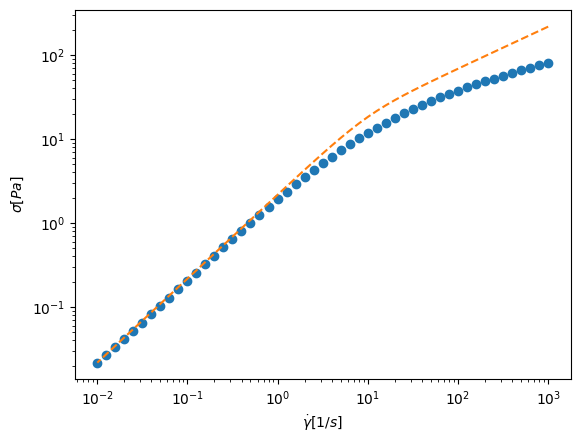

In [30]:
params['carreau_eta_0'].set(value=data['Viscosity / Pa.s'].max())
params['carreau_gammadot_crit'].set(value=10)
params['carreau_n'].set(value=0.5)
params['carreau_eta_inf'].set(value=0,vary=False)
plot_data(data)
plt.plot(data['Shear rate / 1/s'],model.eval(x=data['Shear rate / 1/s'], params=params),'--')

In [33]:
res_fit=model.fit(data['Stress / Pa'],
                  x=data['Shear rate / 1/s'],
                  weights=1/(data['Stress / Pa'])*0.05,
                  method='least_squares',
                  params=params)
res_fit

## Plotting Fit results

The fit method returns a fit result object that contains all the information on the data, the model used and the results

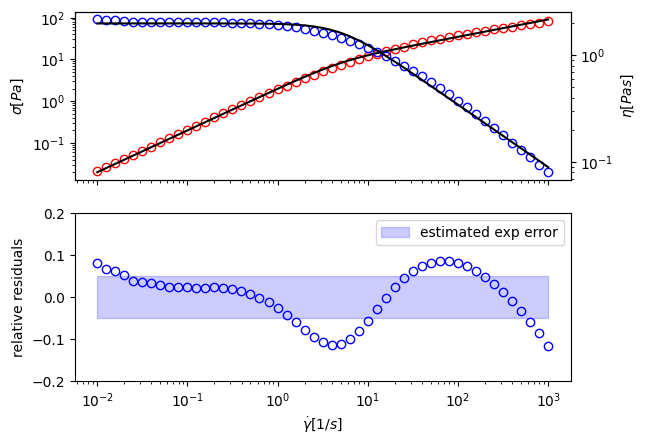

In [34]:
rheofit.visualization.plot_fit_res(res_fit);

## Explore fit results with pybroom
Exploring the lmfit.fit_result object is not intuitive, using the convenient [pybroom](https://pybroom.readthedocs.io/en/stable/) library make things very easy, especially when we explore lists of results from different sample. 

In [35]:
pb.glance(res_fit)

c:\Users\caggioni.m\Documents\rheofit\.venv\Lib\site-packages\pybroom.py:458: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return d.apply(pd.to_numeric, errors='ignore')


,model,method,num_params,num_data_points,chisqr,redchi,AIC,BIC,num_func_eval,success,message
0,"Model(carreau, prefix='carreau_')",least_squares,3,51,0.000462,0.00001,-586.243211,-580.447734,44,True,`gtol` termination condition is satisfied.


In [36]:
pb.tidy(res_fit)

c:\Users\caggioni.m\Documents\rheofit\.venv\Lib\site-packages\pybroom.py:328: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return d.apply(pd.to_numeric, errors='ignore')


,name,value,min,max,vary,expr,stderr,init_value
0,carreau_eta_0,1.991896,0,inf,True,NaN,0.025240,2.168891
1,carreau_eta_inf,0.000000,0,inf,False,NaN,0.000000,0.000000
2,carreau_gammadot_crit,5.020246,0,inf,True,NaN,0.311785,10.000000
3,carreau_n,0.414452,0,1.0,True,NaN,0.009392,0.500000


In [37]:
augmented=pb.augment(res_fit)
augmented.head()

c:\Users\caggioni.m\Documents\rheofit\.venv\Lib\site-packages\pybroom.py:484: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return d.apply(pd.to_numeric, errors='ignore')


,x,data,best_fit,residual
0,1000.000427,80.423111,89.728035,-0.005785
1,794.328369,75.157867,81.560713,-0.004260
2,630.959473,70.067650,74.136724,-0.002904
3,501.187347,65.242455,67.388051,-0.001644
4,398.107056,60.695656,61.253388,-0.000459


## Plot residuals

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\caggioni.m\AppData\Local\Temp\ipykernel_20472\618563654.py:6: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('$\dot\gamma [1/s]$');
c:\Users\caggioni.m\Documents\rheofit\.venv\Lib\site-packages\pybroom.py:484: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return d.apply(pd.to_numeric, errors='ignore')


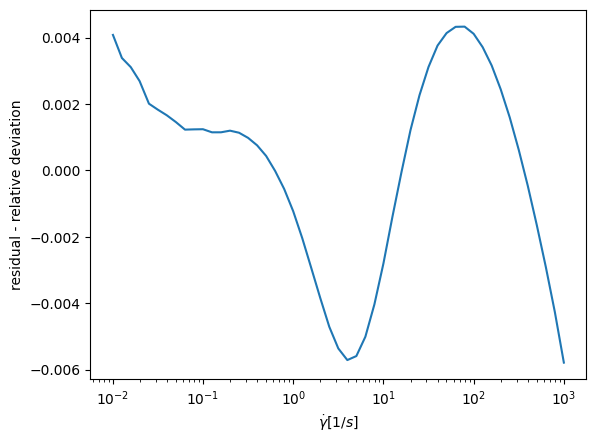

In [38]:
def plot_residuals(res_fit):
    augmented=pb.augment(res_fit)
    plt.plot('x','residual',data=augmented)
    plt.xscale('log')
    plt.ylabel('residual - relative deviation');
    plt.xlabel('$\dot\gamma [1/s]$');
    
    return plt.gcf()

plot_residuals(res_fit);

## Confidence interval

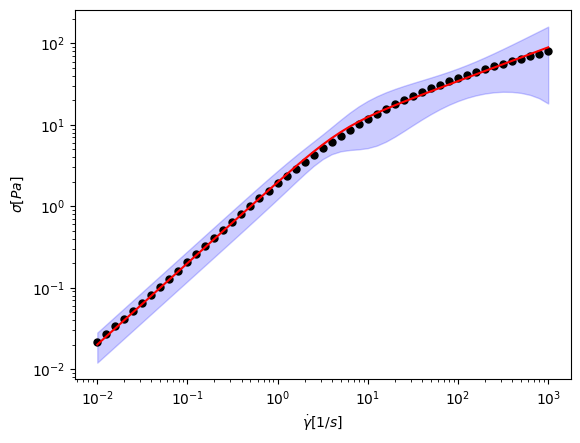

In [39]:
def plot_confidence(res_fit,expand=10):
    dely = res_fit.eval_uncertainty(x=res_fit.userkws['x'],sigma=3)*expand
    
    plt.plot(res_fit.userkws['x'], res_fit.data,'o',color='black',label='Data',markersize=5)
    plt.plot(res_fit.userkws['x'], res_fit.best_fit,label='Best fit TC model',color='red')
    plt.fill_between(res_fit.userkws['x'], res_fit.best_fit-dely,res_fit.best_fit+dely,
                     color='blue',alpha=0.2,label='0.9973 Confidence interval')
    plt.yscale('log')
    plt.xscale('log')
    plt.ylabel(r'$\sigma [Pa]$')
    plt.xlabel(r'$\dot\gamma [1/s]$')
    
    return plt.gcf()

plot_confidence(res_fit);

## Fit specific shear rate range

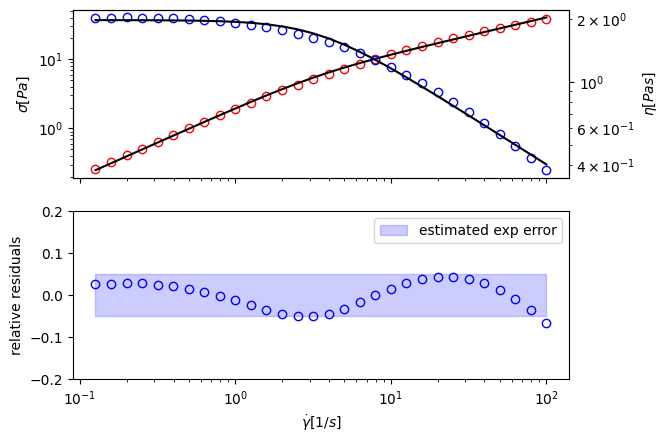

In [15]:
min_shear_rate=0.1
max_shear_rate=1000

def fit_range(res_fit,min_shear_rate=0.1,max_shear_rate=100):
    data=pd.DataFrame.from_dict({'Shear rate / 1/s':res_fit.userkws['x'],'Stress / Pa':res_fit.data})
    mask=(data['Shear rate / 1/s']>=min_shear_rate) & (data['Shear rate / 1/s']<=max_shear_rate)
    res_fit=model.fit(data[mask]['Stress / Pa'],x=data[mask]['Shear rate / 1/s'],weights=1/(data[mask]['Stress / Pa']))
    return res_fit

rheofit.visualization.plot_fit_res(fit_range(res_fit));